Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0077 - val_loss: 0.0039
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0053 - val_loss: 0.0025
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0046 - val_loss: 0.0018
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0037 - val_loss: 8.2936e-04
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0028 - val_loss: 1.8443e-04
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0025 - val_loss: 1.6519e-05
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0024 - val_loss: 9.3259e-06
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0024 - val_loss: 2.5126e-05
Epoch 9/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0023 - val_loss: 1.9830e-05
Epoch 10/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0023 - val_loss: 1.8556e-05
Epoch 11/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0023 - val_loss: 1.4208e-05
Epoch 12/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s

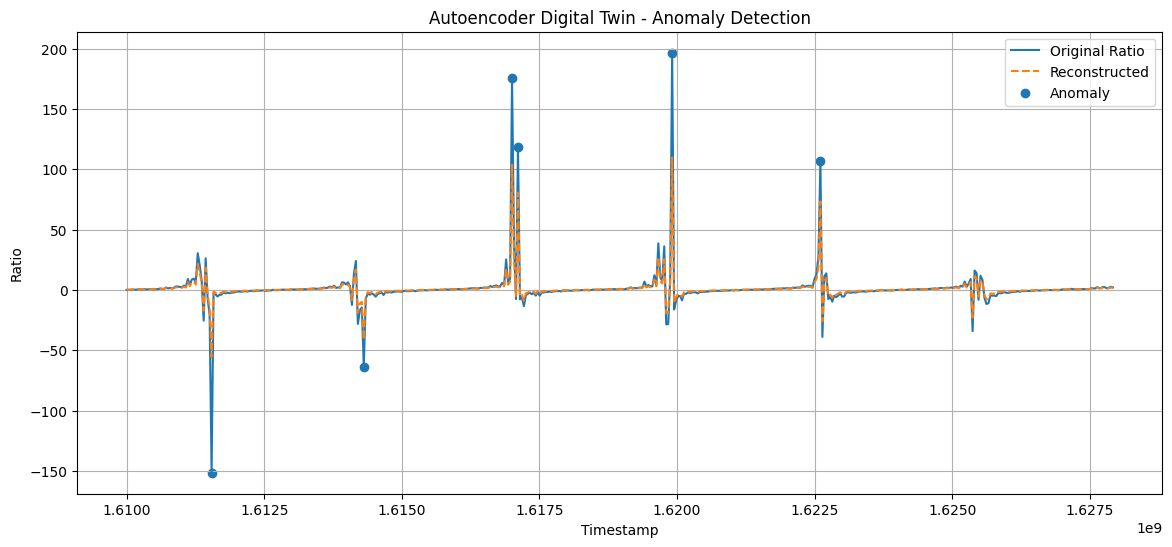

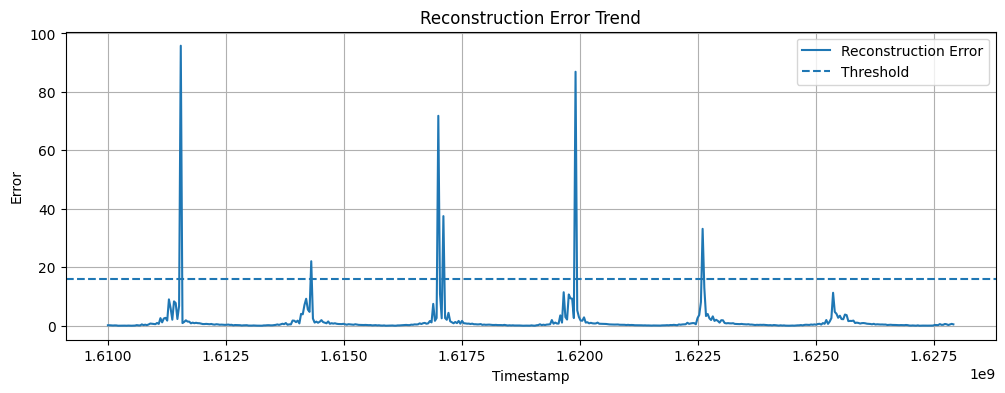


--- DATA WITH ANOMALIES ---
      timestamp    amount0    amount1     ratio  reconstruction_error  anomaly
0  1.610000e+09   4.967142  87.409420  0.056826              0.153650    False
1  1.610036e+09   2.624300  95.211085  0.027563              0.162669    False
2  1.610072e+09  14.484335  68.554570  0.211282              0.105987    False
3  1.610108e+09  27.225394  83.926139  0.324397              0.071084    False
4  1.610144e+09  13.621941  73.768951  0.184657              0.114185    False


In [1]:
# ==============================
# 1. INSTALL & IMPORT LIBRARIES
# ==============================
!pip install tensorflow

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from sklearn.preprocessing import MinMaxScaler

# ==============================
# 2. GENERATE / LOAD DATA
# ==============================
def generate_digital_twin_data(start, end):
    np.random.seed(42)

    timestamps = np.linspace(start, end, 500)

    amount0 = np.sin(np.linspace(0, 20, 500)) * 100 + np.random.normal(0, 10, 500)
    amount1 = np.cos(np.linspace(0, 20, 500)) * 80 + np.random.normal(0, 8, 500)

    df = pd.DataFrame({
        'timestamp': timestamps,
        'amount0': amount0,
        'amount1': amount1
    })

    df['ratio'] = df['amount0'] / (df['amount1'] + 1e-18)

    return df

df = generate_digital_twin_data(1610000000, 1627918115)

# ==============================
# 3. PREPROCESS DATA
# ==============================
data = df[['ratio']].values

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

# ==============================
# 4. BUILD AUTOENCODER MODEL
# ==============================
input_dim = data_scaled.shape[1]

input_layer = Input(shape=(input_dim,))
encoder = Dense(8, activation="relu")(input_layer)
encoder = Dense(4, activation="relu")(encoder)

decoder = Dense(8, activation="relu")(encoder)
decoder = Dense(input_dim, activation="sigmoid")(decoder)

autoencoder = Model(inputs=input_layer, outputs=decoder)
autoencoder.compile(optimizer='adam', loss='mse')

# ==============================
# 5. TRAIN MODEL
# ==============================
history = autoencoder.fit(
    data_scaled, data_scaled,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# ==============================
# 6. RECONSTRUCTION
# ==============================
reconstructed = autoencoder.predict(data_scaled)

# Convert back to original scale
reconstructed = scaler.inverse_transform(reconstructed)

# ==============================
# 7. ANOMALY DETECTION
# ==============================
reconstruction_error = np.mean(np.abs(data - reconstructed), axis=1)

threshold = np.mean(reconstruction_error) + 2 * np.std(reconstruction_error)

df['reconstruction_error'] = reconstruction_error
df['anomaly'] = df['reconstruction_error'] > threshold

# ==============================
# 8. VISUALIZATION
# ==============================
plt.figure(figsize=(14, 6))

# Original vs Reconstructed
plt.plot(df['timestamp'], df['ratio'], label='Original Ratio')
plt.plot(df['timestamp'], reconstructed, linestyle='--', label='Reconstructed')

# Highlight anomalies
anomalies = df[df['anomaly']]
plt.scatter(anomalies['timestamp'], anomalies['ratio'], label='Anomaly')

plt.title("Autoencoder Digital Twin - Anomaly Detection")
plt.xlabel("Timestamp")
plt.ylabel("Ratio")
plt.legend()
plt.grid(True)
plt.show()

# ==============================
# 9. ERROR PLOT
# ==============================
plt.figure(figsize=(12, 4))
plt.plot(df['timestamp'], reconstruction_error, label='Reconstruction Error')
plt.axhline(threshold, linestyle='--', label='Threshold')

plt.title("Reconstruction Error Trend")
plt.xlabel("Timestamp")
plt.ylabel("Error")
plt.legend()
plt.grid(True)
plt.show()

# ==============================
# 10. OUTPUT SAMPLE
# ==============================
print("\n--- DATA WITH ANOMALIES ---")
print(df.head())